In [1]:
import pandas as pd

# Load BTC CSV
btc_df = pd.read_csv(r'feature_datasets\BTC_features.csv', parse_dates=True, index_col=0)

# Define X and y
btc_y = btc_df['Close'].shift(-1)          # next-day close price
btc_X = btc_df.drop(columns=['Close'])     # all other features

# Drop last row (y will be NaN)
btc_X = btc_X.iloc[:-1]
btc_y = btc_y.iloc[:-1]

# check shapes
print("BTC X shape:", btc_X.shape)
print("BTC y shape:", btc_y.shape)

BTC X shape: (915, 29)
BTC y shape: (915,)


## Basic 70-30 split

In [2]:
# 70% train / 30% test split (time-based)
split_idx = int(len(btc_X) * 0.7)

btc_X_train = btc_X.iloc[:split_idx].values
btc_X_test  = btc_X.iloc[split_idx:].values

btc_y_train = btc_y.iloc[:split_idx].values
btc_y_test  = btc_y.iloc[split_idx:].values

# Optional: check shapes
print("BTC X_train shape:", btc_X_train.shape)
print("BTC X_test shape:", btc_X_test.shape)
print("BTC y_train shape:", btc_y_train.shape)
print("BTC y_test shape:", btc_y_test.shape)

BTC X_train shape: (640, 29)
BTC X_test shape: (275, 29)
BTC y_train shape: (640,)
BTC y_test shape: (275,)


In [3]:
# ! pip install --upgrade pip

In [4]:
# pip install scikit-learn

In [5]:
# Assuming btc_df has Date as index
# After splitting your data 70-30
btc_test_dates = btc_df.index[-len(btc_X_test):]  # get the dates for test set

In [6]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Initialize scaler
scaler = MinMaxScaler()

# Fit on TRAIN only
btc_X_train_scaled = scaler.fit_transform(btc_X_train)

# Transform TEST using the same scaler
btc_X_test_scaled = scaler.transform(btc_X_test)

# Check shapes
print("Scaled X_train shape:", btc_X_train_scaled.shape)
print("Scaled X_test shape:", btc_X_test_scaled.shape)

Scaled X_train shape: (640, 29)
Scaled X_test shape: (275, 29)


In [7]:
# Initialize scaler for y
y_scaler = MinMaxScaler()

# Scale training target
btc_y_train_scaled = y_scaler.fit_transform(btc_y_train.reshape(-1,1)).flatten()

# Scale test target
btc_y_test_scaled = y_scaler.transform(btc_y_test.reshape(-1,1)).flatten()

In [8]:
def create_sequences(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i+time_steps])
        y_seq.append(y[i+time_steps])  # the next day after the sequence
    return np.array(X_seq), np.array(y_seq)

# Create sequences for BTC using scaled target
btc_X_train_seq, btc_y_train_seq = create_sequences(btc_X_train_scaled, btc_y_train_scaled, time_steps=30)
btc_X_test_seq, btc_y_test_seq = create_sequences(btc_X_test_scaled, btc_y_test_scaled, time_steps=30)

# Check shapes
print("BTC X_train_seq shape:", btc_X_train_seq.shape)
print("BTC y_train_seq shape:", btc_y_train_seq.shape)
print("BTC X_test_seq shape:", btc_X_test_seq.shape)
print("BTC y_test_seq shape:", btc_y_test_seq.shape)

BTC X_train_seq shape: (610, 30, 29)
BTC y_train_seq shape: (610,)
BTC X_test_seq shape: (245, 30, 29)
BTC y_test_seq shape: (245,)


### Training the model for the basic split

In [9]:
from Bi_LSTM import BiLSTM, train_model, predict_model

In [10]:
# Get number of features from the sequences
input_size = btc_X_train_seq.shape[2]

# Initialize Bi-LSTM model
model = BiLSTM(input_size=input_size)

In [11]:
model = train_model(
    model,
    btc_X_train_seq,
    btc_y_train_seq,
    epochs=50,       # you can adjust later
    batch_size=32,
    lr=0.001
)

Epoch [10/50], Loss: 0.002775
Epoch [20/50], Loss: 0.001440
Epoch [30/50], Loss: 0.004051
Epoch [40/50], Loss: 0.001289
Epoch [50/50], Loss: 0.002540


In [12]:
btc_preds = predict_model(model, btc_X_test_seq)

# Optional: check
print("Predictions shape:", btc_preds.shape)
print("First 10 predictions:", btc_preds[:10])

Predictions shape: (245, 1)
First 10 predictions: [[0.25784558]
 [0.24239573]
 [0.23525131]
 [0.2259927 ]
 [0.21921143]
 [0.21585757]
 [0.21090683]
 [0.2055005 ]
 [0.198169  ]
 [0.19620962]]


In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Inverse scale predictions
btc_preds_actual = y_scaler.inverse_transform(btc_preds.reshape(-1,1))

# Skip first 30 because of 30-day sequence
btc_y_test_actual = btc_y_test[30:].reshape(-1,1)

# Calculate metrics
mse = mean_squared_error(btc_y_test_actual, btc_preds_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(btc_y_test_actual, btc_preds_actual)
r2 = r2_score(btc_y_test_actual, btc_preds_actual)

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")


MSE: 2759008.38
RMSE: 1661.03
MAE: 1378.31
R2 Score: 0.9105


In [14]:
btc_preds_actual = y_scaler.inverse_transform(btc_preds.reshape(-1,1))

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Skip first 30 because of sequence
dates_seq = btc_df.index[-len(btc_X_test):][30:]  # test dates aligned with sequences
actual_seq = btc_y_test[30:]                      # actual prices aligned
pred_seq = btc_preds_actual                       # predicted prices aligned

# Create DataFrame
df_plot = pd.DataFrame({
    "Date": dates_seq,
    "Actual": actual_seq,
    "Predicted": pred_seq.flatten()
})

df_plot.set_index("Date", inplace=True)
df_plot

,Actual,Predicted
Date,,
2023-05-02,28680.537109,29138.410156
2023-05-03,29006.308594,28338.425781
2023-05-04,28847.710938,27968.488281
2023-05-05,29534.384766,27489.083984
2023-05-06,28904.623047,27137.953125
...,...,...
2023-12-28,42627.855469,40064.578125
2023-12-29,42099.402344,40100.519531
2023-12-30,42156.902344,40518.699219


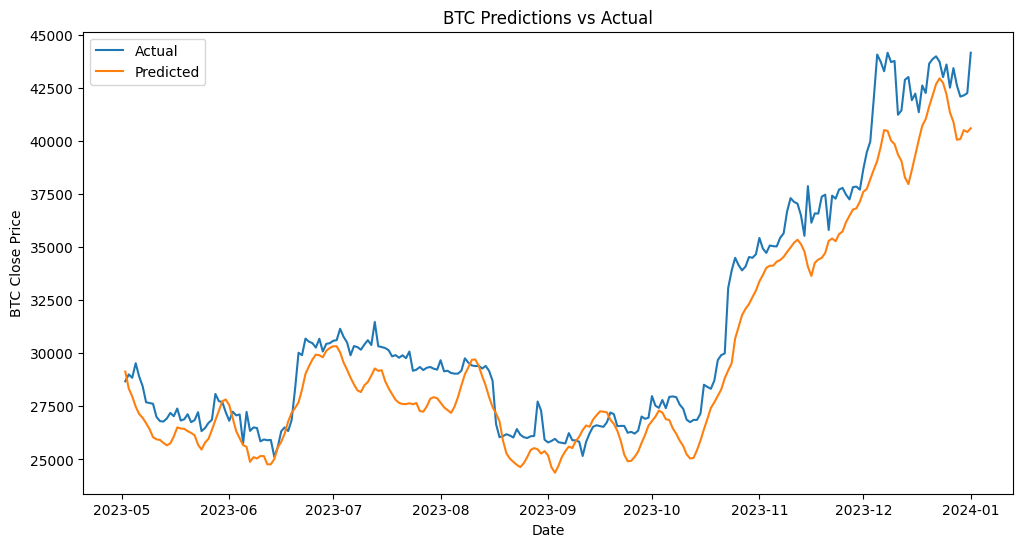

In [16]:
plt.figure(figsize=(12,6))
plt.plot(df_plot["Actual"], label="Actual")
plt.plot(df_plot["Predicted"], label="Predicted")
plt.xlabel("Date")
plt.ylabel("BTC Close Price")
plt.title("BTC Predictions vs Actual")
plt.legend()
plt.show()

## Each year 70% train split

### Preparing the train and test datasets

In [17]:
# Get unique years from your DataFrame index
years = btc_df.index.year.unique()
print("Years in dataset:", years)

Years in dataset: Index([2021, 2022, 2023, 2024], dtype='int32', name='Date')


In [18]:
X_train_list = []
y_train_list = []

In [19]:
for year in years:
    # Filter data for this year
    btc_year = btc_df[btc_df.index.year == year]

    # Calculate split index for 70%
    split_idx = int(len(btc_year) * 0.7)

    # Take first 70% as training
    X_train_year = btc_year.iloc[:split_idx, 1:].values  # all features except target column
    y_train_year = btc_year.iloc[:split_idx, 0].values   # target column (e.g., next-day Close)

    # Append to lists
    X_train_list.append(X_train_year)
    y_train_list.append(y_train_year)

    print(f"Year {year}: {len(X_train_year)} train samples")

Year 2021: 129 train samples
Year 2022: 255 train samples
Year 2023: 255 train samples
Year 2024: 0 train samples


In [20]:
import numpy as np

# Stack all years’ train sets
X_train_combined = np.vstack(X_train_list)
y_train_combined = np.hstack(y_train_list)

print("Combined X_train shape:", X_train_combined.shape)
print("Combined y_train shape:", y_train_combined.shape)

Combined X_train shape: (639, 29)
Combined y_train shape: (639,)


In [21]:
X_test_list = []
y_test_list = []

In [22]:
for year in years:
    btc_year = btc_df[btc_df.index.year == year]

    # Calculate split index (same as for train)
    split_idx = max(1, int(len(btc_year) * 0.7))  # ensures at least 1 sample in train

    # Take the remaining 30% as test
    X_test_year = btc_year.iloc[split_idx:, 1:].values   # features
    y_test_year = btc_year.iloc[split_idx:, 0].values    # target

    # Append to test lists
    X_test_list.append(X_test_year)
    y_test_list.append(y_test_year)

    print(f"Year {year}: {len(X_test_year)} test samples")


Year 2021: 56 test samples
Year 2022: 110 test samples
Year 2023: 110 test samples
Year 2024: 0 test samples


In [23]:
import numpy as np

X_test_combined = np.vstack(X_test_list)
y_test_combined = np.hstack(y_test_list)

print("Combined X_test shape:", X_test_combined.shape)
print("Combined y_test shape:", y_test_combined.shape)

Combined X_test shape: (276, 29)
Combined y_test shape: (276,)


In [24]:
from sklearn.preprocessing import MinMaxScaler

# Initialize scalers
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

# Scale training data
X_train_scaled = x_scaler.fit_transform(X_train_combined)
y_train_scaled = y_scaler.fit_transform(y_train_combined.reshape(-1,1)).flatten()

In [25]:
X_test_scaled = x_scaler.transform(X_test_combined)
y_test_scaled = y_scaler.transform(y_test_combined.reshape(-1,1)).flatten()

In [26]:
print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape:", X_test_scaled.shape)
print("Scaled y_train shape:", y_train_scaled.shape)
print("Scaled y_test shape:", y_test_scaled.shape)


Scaled X_train shape: (639, 29)
Scaled X_test shape: (276, 29)
Scaled y_train shape: (639,)
Scaled y_test shape: (276,)


In [27]:
import numpy as np

def create_sequences(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i+time_steps])
        y_seq.append(y[i+time_steps])  # the next day after the sequence
    return np.array(X_seq), np.array(y_seq)

# Create sequences for train and test
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled)

# Check shapes
print("X_train_seq shape:", X_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)
print("X_test_seq shape:", X_test_seq.shape)
print("y_test_seq shape:", y_test_seq.shape)

X_train_seq shape: (609, 30, 29)
y_train_seq shape: (609,)
X_test_seq shape: (246, 30, 29)
y_test_seq shape: (246,)


### Training the model for each year 70% train

In [28]:
from Bi_LSTM import BiLSTM, train_model, predict_model

In [29]:
# Get number of features from the sequences
input_size = X_train_seq.shape[2]   # use the combined train sequences

# Initialize Bi-LSTM model
model_y = BiLSTM(input_size=input_size)

In [30]:
model_y = train_model(model_y, X_train_seq, y_train_seq, epochs=50, batch_size=32, lr=0.001)

c:\Users\tharu\anaconda3\envs\Streamlit\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch [10/50], Loss: 0.003317
Epoch [20/50], Loss: 0.004529
Epoch [30/50], Loss: 0.002434
Epoch [40/50], Loss: 0.001121
Epoch [50/50], Loss: 0.004110


In [31]:
btc_preds_ev_year = predict_model(model_y, X_test_seq)
btc_preds_ev_year[:10]

array([[0.6073644 ],
       [0.609336  ],
       [0.620812  ],
       [0.622659  ],
       [0.60777646],
       [0.58610773],
       [0.5830822 ],
       [0.59173447],
       [0.57033914],
       [0.5469198 ]], dtype=float32)

In [32]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predict using the trained model
btc_preds_ev_year = predict_model(model_y, X_test_seq)

# Inverse scale predictions to original price values
btc_preds_actual = y_scaler.inverse_transform(btc_preds_ev_year.reshape(-1,1))

# Inverse scale the test targets
btc_y_test_actual = y_scaler.inverse_transform(y_test_seq.reshape(-1,1))

# Calculate metrics
mse = mean_squared_error(btc_y_test_actual, btc_preds_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(btc_y_test_actual, btc_preds_actual)
r2 = r2_score(btc_y_test_actual, btc_preds_actual)

# Print results
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")

MSE: 11428368.66
RMSE: 3380.59
MAE: 2578.81
R2 Score: 0.9085


In [33]:
btc_preds_actual = y_scaler.inverse_transform(btc_preds_ev_year.reshape(-1, 1))

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# Actual and predicted prices
actual_test_seq = y_scaler.inverse_transform(y_test_seq.reshape(-1,1)).flatten()
predicted_test_seq = btc_preds_actual.flatten()

# Create DataFrame for plotting (no Date index)
df_btc_plot_year = pd.DataFrame({
    "Actual": actual_test_seq,
    "Predicted": predicted_test_seq
})

# Display first few rows
df_btc_plot_year.head()

,Actual,Predicted
0,50582.625000,46609.296875
1,50700.085938,46706.628906
2,50504.796875,47273.175781
3,47672.121094,47364.359375
4,47243.304688,46629.640625


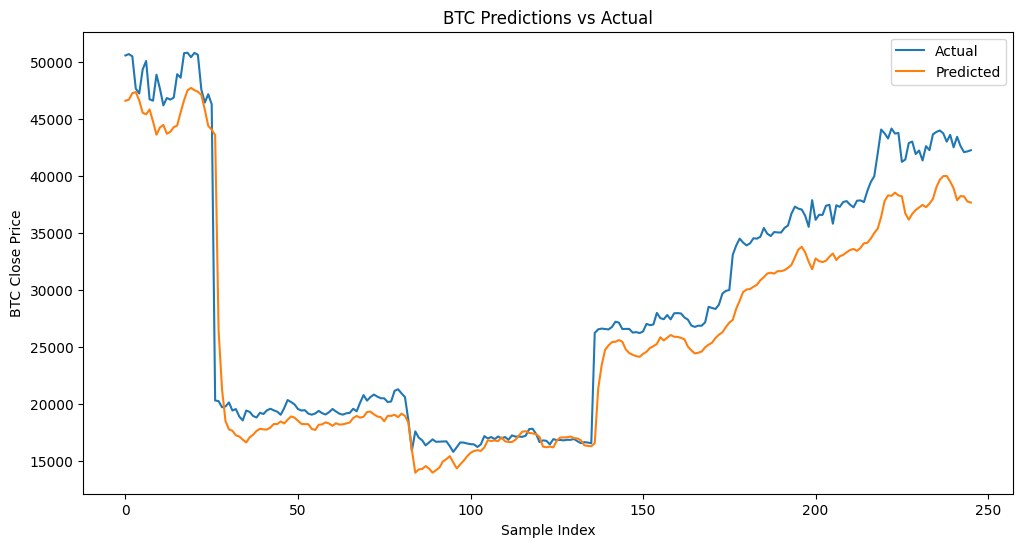

In [35]:
# Plot
plt.figure(figsize=(12,6))
plt.plot(df_btc_plot_year["Actual"], label="Actual")
plt.plot(df_btc_plot_year["Predicted"], label="Predicted")
plt.xlabel("Sample Index")
plt.ylabel("BTC Close Price")
plt.title("BTC Predictions vs Actual")
plt.legend()
plt.show()

## Three quarters train (all years-75%)

### Preparing the train and test datasets

In [36]:
# 75% train / 25% test split (time-based)
q3_split_idx = int(len(btc_X) * 0.75)

btc_q3_X_train = btc_X.iloc[:q3_split_idx].values
btc_q3_X_test  = btc_X.iloc[q3_split_idx:].values

btc_q3_y_train = btc_y.iloc[:q3_split_idx].values
btc_q3_y_test  = btc_y.iloc[q3_split_idx:].values

# Shape checks
print("Q3 BTC X_train shape:", btc_q3_X_train.shape)
print("Q3 BTC X_test shape:", btc_q3_X_test.shape)
print("Q3 BTC y_train shape:", btc_q3_y_train.shape)
print("Q3 BTC y_test shape:", btc_q3_y_test.shape)

Q3 BTC X_train shape: (686, 29)
Q3 BTC X_test shape: (229, 29)
Q3 BTC y_train shape: (686,)
Q3 BTC y_test shape: (229,)


In [37]:
# Assuming btc_df has Date as index
btc_q3_test_dates = btc_df.index[-len(btc_q3_X_test):]

print("Q3 test dates length:", len(btc_q3_test_dates))

Q3 test dates length: 229


In [38]:
from sklearn.preprocessing import MinMaxScaler

# Feature scaler
btc_q3_X_scaler = MinMaxScaler()

# Fit on TRAIN only
btc_q3_X_train_scaled = btc_q3_X_scaler.fit_transform(btc_q3_X_train)

# Transform TEST using same scaler
btc_q3_X_test_scaled = btc_q3_X_scaler.transform(btc_q3_X_test)

print("Q3 Scaled X_train shape:", btc_q3_X_train_scaled.shape)
print("Q3 Scaled X_test shape:", btc_q3_X_test_scaled.shape)


Q3 Scaled X_train shape: (686, 29)
Q3 Scaled X_test shape: (229, 29)


In [39]:
# Target scaler
btc_q3_y_scaler = MinMaxScaler()

# Scale training target
btc_q3_y_train_scaled = btc_q3_y_scaler.fit_transform(
    btc_q3_y_train.reshape(-1, 1)
).flatten()

# Scale test target
btc_q3_y_test_scaled = btc_q3_y_scaler.transform(
    btc_q3_y_test.reshape(-1, 1)
).flatten()
14
print("Q3 Scaled y_train shape:", btc_q3_y_train_scaled.shape)
print("Q3 Scaled y_test shape:", btc_q3_y_test_scaled.shape)

Q3 Scaled y_train shape: (686,)
Q3 Scaled y_test shape: (229,)


In [40]:
import numpy as np

def create_sequences_q3(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i + time_steps])
        y_seq.append(y[i + time_steps])
    return np.array(X_seq), np.array(y_seq)

In [41]:
# Create sequences (30-day window)
btc_q3_X_train_seq, btc_q3_y_train_seq = create_sequences_q3(
    btc_q3_X_train_scaled,
    btc_q3_y_train_scaled,
    time_steps=30
)

btc_q3_X_test_seq, btc_q3_y_test_seq = create_sequences_q3(
    btc_q3_X_test_scaled,
    btc_q3_y_test_scaled,
    time_steps=30
)

# Final shape checks
print("Q3 X_train_seq shape:", btc_q3_X_train_seq.shape)
print("Q3 y_train_seq shape:", btc_q3_y_train_seq.shape)
print("Q3 X_test_seq shape:", btc_q3_X_test_seq.shape)
print("Q3 y_test_seq shape:", btc_q3_y_test_seq.shape)


Q3 X_train_seq shape: (656, 30, 29)
Q3 y_train_seq shape: (656,)
Q3 X_test_seq shape: (199, 30, 29)
Q3 y_test_seq shape: (199,)


### Training the model for three quarters train split

In [42]:
from Bi_LSTM import BiLSTM, train_model, predict_model

In [43]:
# Get number of features
btc_q3_input_size = btc_q3_X_train_seq.shape[2]

# Initialize model
btc_q3_model = BiLSTM(input_size=btc_q3_input_size)

In [44]:
# Train model
btc_q3_model = train_model(
    btc_q3_model,
    btc_q3_X_train_seq,
    btc_q3_y_train_seq,
    epochs=50,
    batch_size=32,
    lr=0.001
)

Epoch [10/50], Loss: 0.001609
Epoch [20/50], Loss: 0.001572
Epoch [30/50], Loss: 0.006821
Epoch [40/50], Loss: 0.001320
Epoch [50/50], Loss: 0.001427


In [45]:
# Generate predictions
btc_q3_preds = predict_model(btc_q3_model, btc_q3_X_test_seq)

print("Q3 Predictions shape:", btc_q3_preds.shape)
print("First 10 Q3 predictions:", btc_q3_preds[:10])

Q3 Predictions shape: (199, 1)
First 10 Q3 predictions: [[0.20183797]
 [0.21109952]
 [0.21488033]
 [0.21643038]
 [0.2222711 ]
 [0.23609228]
 [0.25144336]
 [0.2544402 ]
 [0.26457888]
 [0.2635231 ]]


In [46]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predict using the Q3 trained model
btc_q3_preds_eval = predict_model(btc_q3_model, btc_q3_X_test_seq)

# Inverse scale predictions to original price values
btc_q3_preds_actual = btc_q3_y_scaler.inverse_transform(
    btc_q3_preds_eval.reshape(-1, 1)
)

# Inverse scale the test targets
btc_q3_y_test_actual = btc_q3_y_scaler.inverse_transform(
    btc_q3_y_test_seq.reshape(-1, 1)
)

# Calculate metrics
btc_q3_mse = mean_squared_error(btc_q3_y_test_actual, btc_q3_preds_actual)
btc_q3_rmse = np.sqrt(btc_q3_mse)
btc_q3_mae = mean_absolute_error(btc_q3_y_test_actual, btc_q3_preds_actual)
btc_q3_r2 = r2_score(btc_q3_y_test_actual, btc_q3_preds_actual)

# Print results
print(f"Q3 MSE: {btc_q3_mse:.2f}")
print(f"Q3 RMSE: {btc_q3_rmse:.2f}")
print(f"Q3 MAE: {btc_q3_mae:.2f}")
print(f"Q3 R2 Score: {btc_q3_r2:.4f}")


Q3 MSE: 5716404.75
Q3 RMSE: 2390.90
Q3 MAE: 1865.25
Q3 R2 Score: 0.8272


In [47]:
# Inverse scale predictions
btc_q3_preds_actual = btc_q3_y_scaler.inverse_transform(
    btc_q3_preds.reshape(-1, 1)
)

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# Align dates and values
btc_q3_dates_seq = btc_df.index[-len(btc_q3_X_test):][30:]
btc_q3_actual_seq = btc_q3_y_test[30:]
btc_q3_pred_seq = btc_q3_preds_actual.flatten()

# Create DataFrame
btc_q3_df_plot = pd.DataFrame({
    "Date": btc_q3_dates_seq,
    "Actual": btc_q3_actual_seq,
    "Predicted": btc_q3_pred_seq
})

btc_q3_df_plot.set_index("Date", inplace=True)
btc_q3_df_plot


,Actual,Predicted
Date,,
2023-06-17,26510.675781,26238.363281
2023-06-18,26336.212891,26717.921875
2023-06-19,26851.029297,26913.689453
2023-06-20,28327.488281,26993.951172
2023-06-21,30027.296875,27296.380859
...,...,...
2023-12-28,42627.855469,38342.253906
2023-12-29,42099.402344,38697.980469
2023-12-30,42156.902344,38931.437500


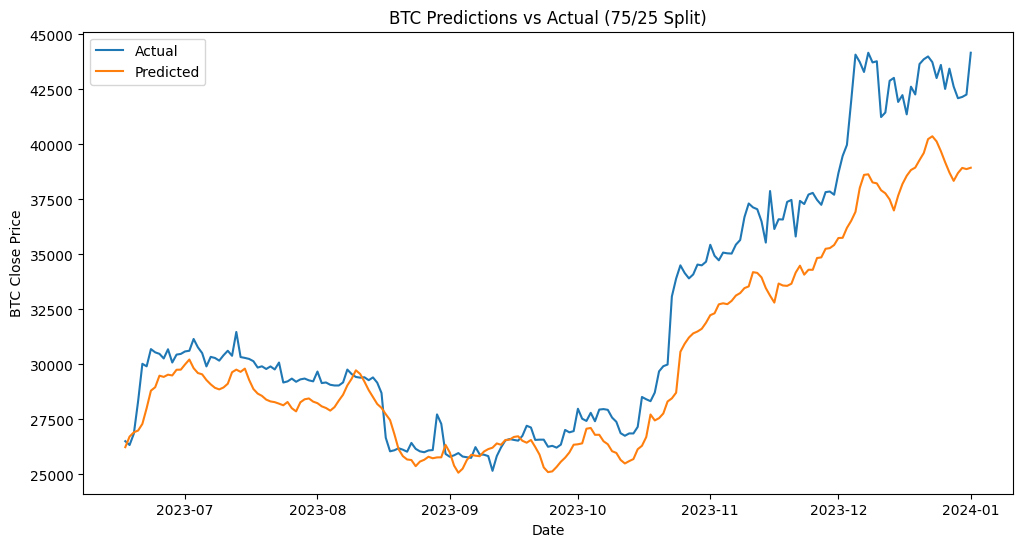

In [49]:
plt.figure(figsize=(12, 6))
plt.plot(btc_q3_df_plot["Actual"], label="Actual")
plt.plot(btc_q3_df_plot["Predicted"], label="Predicted")
plt.xlabel("Date")
plt.ylabel("BTC Close Price")
plt.title("BTC Predictions vs Actual (75/25 Split)")
plt.legend()
plt.show()